# Sales Forecasting using Facebook Prophet

## Business Problem

Retail companies require accurate sales forecasts to optimize inventory,
staffing, procurement, and marketing decisions.

This notebook builds a time-series forecasting model using Facebook Prophet
to predict future daily sales based on historical transaction data.

The forecast enables proactive decision-making and supports demand planning.

### What is Time Series?

A time series is a sequence of observations collected over time.

Examples:

Daily sales
Monthly revenue
Hourly website traffic
Weekly demand

Unlike normal machine learning, time matters because observations are ordered chronologically.

### What is Forecasting?

Forecasting means predicting future values based on historical data.

Business examples:

Predict next month's revenue.
Estimate customer demand.
Forecast inventory requirements.
Plan warehouse capacity.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

pd.set_option("display.max_columns", None)

In [16]:
import pandas as pd

df = pd.read_csv(
    "../data/cleaned/sales_features.csv",
    parse_dates=["InvoiceDate"]
)

daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["ds", "y"]
daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

daily_sales.head()

,ds,y
0,2009-12-01,54351.23
1,2009-12-02,63172.58
2,2009-12-03,73972.45
3,2009-12-04,40582.32
4,2009-12-05,9803.05


In [17]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

print(model)

In [18]:
model.fit(daily_sales)

01:56:44 - cmdstanpy - INFO - Chain [1] start processing
01:56:44 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
daily_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   ds      307 non-null    datetime64[s]
 1   y       307 non-null    float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 4.9 KB


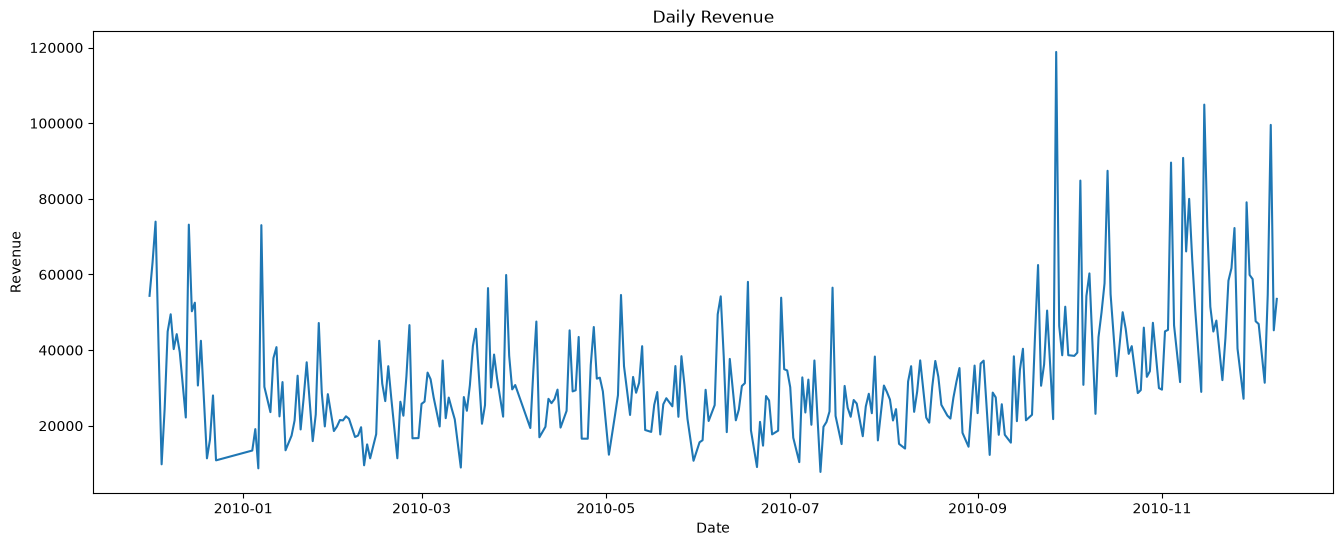

In [21]:
plt.figure(figsize=(16,6))

plt.plot(
    daily_sales["ds"],
    daily_sales["y"]
)

plt.title("Daily Revenue")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.show()

In [22]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [23]:
model.fit(daily_sales)

01:58:58 - cmdstanpy - INFO - Chain [1] start processing
01:58:59 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
future = model.make_future_dataframe(periods=90)

future.head()


,ds
0,2009-12-01
1,2009-12-02
2,2009-12-03
3,2009-12-04
4,2009-12-05


In [25]:
future.tail()

,ds
392,2011-03-05
393,2011-03-06
394,2011-03-07
395,2011-03-08
396,2011-03-09


In [26]:
#Generate Forecast

forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,26633.651266,43082.167928,71745.746705,26633.651266,26633.651266,31239.845320,31239.845320,31239.845320,10165.728763,10165.728763,10165.728763,21074.116557,21074.116557,21074.116557,0.0,0.0,0.0,57873.496586
1,2009-12-02,26634.437323,38697.533483,66405.050405,26634.437323,26634.437323,25821.259271,25821.259271,25821.259271,5347.216550,5347.216550,5347.216550,20474.042721,20474.042721,20474.042721,0.0,0.0,0.0,52455.696594
2,2009-12-03,26635.223381,44863.330663,73824.163866,26635.223381,26635.223381,32422.719208,32422.719208,32422.719208,12611.851943,12611.851943,12611.851943,19810.867265,19810.867265,19810.867265,0.0,0.0,0.0,59057.942589
3,2009-12-04,26636.009438,33915.481713,62723.410614,26636.009438,26636.009438,22297.547096,22297.547096,22297.547096,3220.069718,3220.069718,3220.069718,19077.477379,19077.477379,19077.477379,0.0,0.0,0.0,48933.556534
4,2009-12-05,26636.795495,-4133.772789,23615.846304,26636.795495,26636.795495,-17310.376403,-17310.376403,-17310.376403,-35577.809743,-35577.809743,-35577.809743,18267.433340,18267.433340,18267.433340,0.0,0.0,0.0,9326.419092


In [27]:
forecast_future = forecast.tail(90)

forecast_future.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
307,2010-12-10,26927.669658,29140.201495,57903.673516,26927.669658,26927.669658,16472.123352,16472.123352,16472.123352,3220.069718,3220.069718,3220.069718,13252.053634,13252.053634,13252.053634,0.0,0.0,0.0,43399.793010
308,2010-12-11,26928.455822,-12863.243697,18103.146239,26928.455822,26928.455822,-23630.190452,-23630.190452,-23630.190452,-35577.809743,-35577.809743,-35577.809743,11947.619291,11947.619291,11947.619291,0.0,0.0,0.0,3298.265370
309,2010-12-12,26929.241986,15631.318225,45679.236081,26929.241986,26929.241987,3580.234789,3580.234789,3580.234789,-6985.045195,-6985.045195,-6985.045195,10565.279984,10565.279984,10565.279984,0.0,0.0,0.0,30509.476776
310,2010-12-13,26930.028150,33151.487904,62553.485903,26930.028150,26930.028154,20331.404086,20331.404086,20331.404086,11217.987964,11217.987964,11217.987964,9113.416122,9113.416122,9113.416122,0.0,0.0,0.0,47261.432236
311,2010-12-14,26930.814314,30144.843599,58934.122630,26930.814310,26930.814321,17768.474085,17768.474085,17768.474085,10165.728763,10165.728763,10165.728763,7602.745323,7602.745323,7602.745323,0.0,0.0,0.0,44699.288400


In [28]:
forecast_future[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].head(15)

,ds,yhat,yhat_lower,yhat_upper
307,2010-12-10,43399.793010,29140.201495,57903.673516
308,2010-12-11,3298.265370,-12863.243697,18103.146239
309,2010-12-12,30509.476776,15631.318225,45679.236081
310,2010-12-13,47261.432236,33151.487904,62553.485903
311,2010-12-14,44699.288400,30144.843599,58934.122630
312,2010-12-15,38324.999493,24466.931874,52433.173609
313,2010-12-16,44002.863620,29318.355053,58011.642028
314,2010-12-17,33009.911240,19065.056795,48904.378308
315,2010-12-18,-7385.590407,-22204.196672,6644.662329
316,2010-12-19,19631.997528,5727.175818,34269.458435


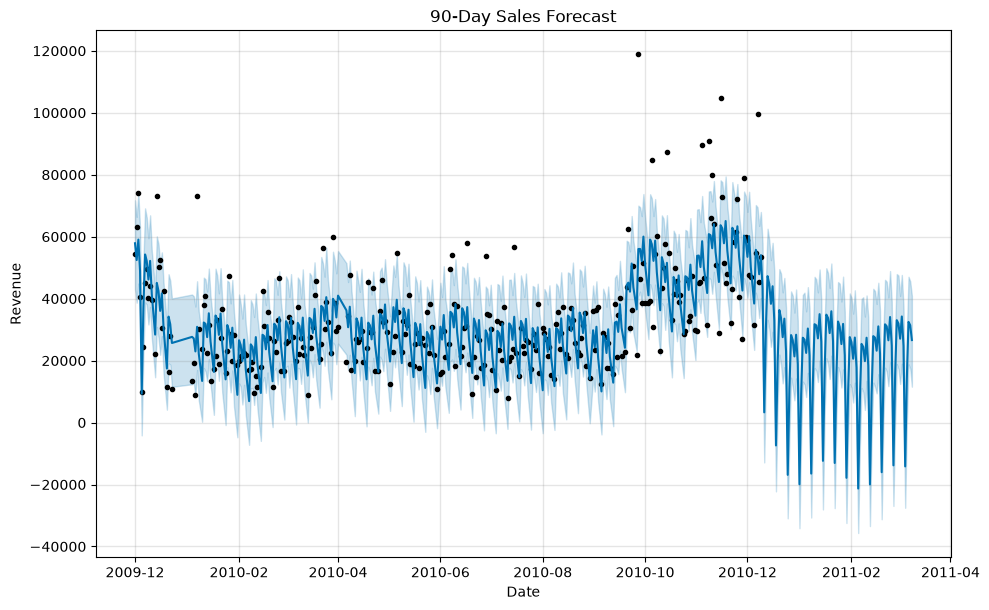

In [29]:
fig = model.plot(forecast)

plt.title("90-Day Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.show()

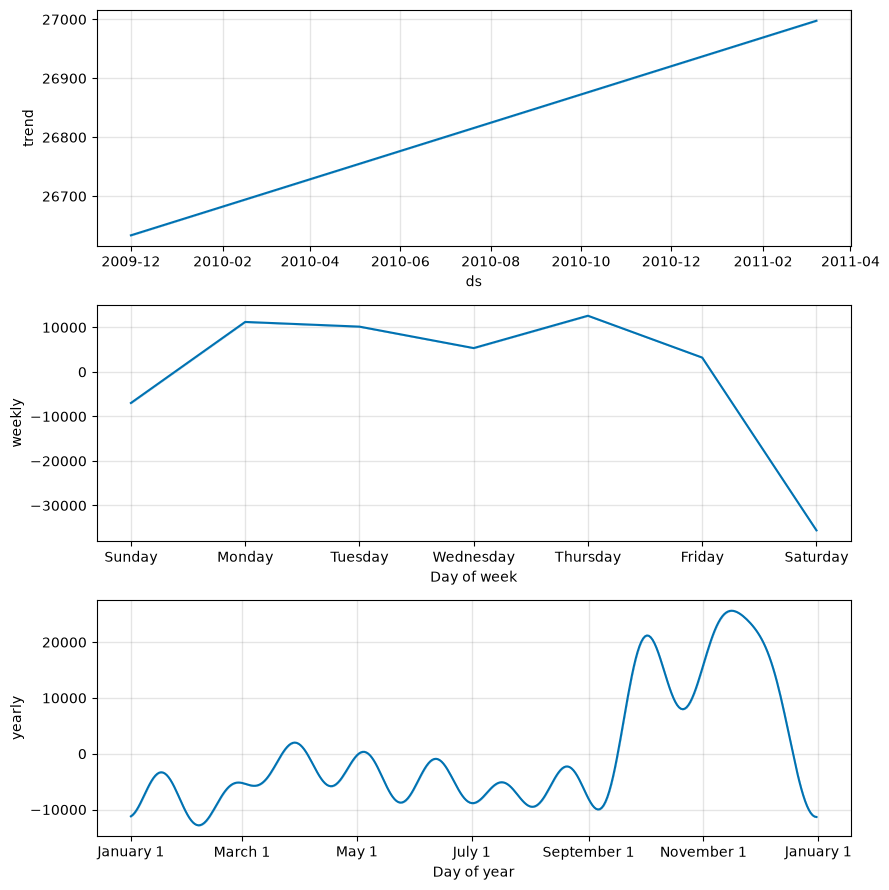

In [30]:
fig2 = model.plot_components(forecast)

In [31]:
forecast_future.to_csv(
    "../data/cleaned/sales_forecast.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.
